In [2]:
# Phase A: Imports and setup

from pathlib import Path
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import f1_score, average_precision_score, classification_report

In [3]:
# Phase B: Reproducibility and project paths

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Project root:", PROJECT_ROOT)
print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")

Project root: c:\Users\farha\code\classical model vs fine tuned transformer vs LLM prompting
Device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


In [4]:
# Phase C: Load the saved train/validation/test splits

label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

train_df = pd.read_csv(DATA_DIR / "train_split.csv")
val_df = pd.read_csv(DATA_DIR / "val_split.csv")
test_df = pd.read_csv(DATA_DIR / "test_split.csv")

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())

Train shape: (111699, 8)
Validation shape: (23936, 8)
Test shape: (23936, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,d52a83440fdc89a7,""" Islands in the Caribbean Wondering why you r...",0,0,0,0,0,0
1,4e1e119b380a5d9e,"""add the complaint, however please read the in...",0,0,0,0,0,0
2,1bfd3b5c49f96bd6,"""I suggest that there be a """"Lincoln High Scho...",0,0,0,0,0,0
3,ebaadb1e33cc8f14,oi I've had enough of your threats mr. Sort yo...,0,0,0,0,0,0
4,27475b04e576e998,Article To Long ?! I am wondering if the Dog a...,0,0,0,0,0,0


In [5]:
# Phase D: Tokenizer setup

MODEL_NAME = "roberta-base"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

c:\Users\farha\code\classical model vs fine tuned transformer vs LLM prompting\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\farha\.cache\huggingface\hub\models--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: roberta-base


In [6]:
# Phase E: PyTorch dataset for multi-label text classification

class ToxicCommentsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, label_cols, max_length=128):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.label_cols = label_cols
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text = str(self.df.loc[idx, "comment_text"])
        labels = self.df.loc[idx, self.label_cols].values.astype(np.float32)

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(labels, dtype=torch.float32)
        }
        return item

In [7]:
# Phase F: Datasets and dataloaders

BATCH_SIZE = 8

train_dataset = ToxicCommentsDataset(train_df, tokenizer, label_cols, max_length=MAX_LENGTH)
val_dataset = ToxicCommentsDataset(val_df, tokenizer, label_cols, max_length=MAX_LENGTH)
test_dataset = ToxicCommentsDataset(test_df, tokenizer, label_cols, max_length=MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 13963
Validation batches: 2992
Test batches: 2992


In [8]:
# Phase G: RoBERTa multi-label classifier

class RobertaForMultiLabelClassification(torch.nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.dropout = torch.nn.Dropout(dropout)
        self.classifier = torch.nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]   # CLS-like position for RoBERTa
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        return logits

model = RobertaForMultiLabelClassification(
    model_name=MODEL_NAME,
    num_labels=len(label_cols)
).to(device)

print("Model created.")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model created.


In [9]:
# Phase H: Loss, optimizer, and training configuration

EPOCHS = 2
LEARNING_RATE = 2e-5

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

print("Training config:")
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)

Training config:
Epochs: 2
Batch size: 8
Learning rate: 2e-05


In [10]:
# Phase I: Training and evaluation helper functions

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(dataloader, desc="Training", leave=False)

    for batch in progress_bar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(dataloader)
    return avg_loss


@torch.no_grad()
def get_probs_and_labels(model, dataloader, device):
    model.eval()

    all_probs = []
    all_labels = []
    total_loss = 0.0

    for batch in tqdm(dataloader, desc="Evaluating", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)
        probs = torch.sigmoid(logits)

        total_loss += loss.item()
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    return avg_loss, all_probs, all_labels

In [11]:
# Phase J: Full training loop with best-model tracking

history = {
    "train_loss": [],
    "val_loss": []
}

best_val_loss = float("inf")
best_model_path = RESULTS_DIR / "best_roberta_model.pt"

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_probs, val_labels = get_probs_and_labels(model, val_loader, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Train loss: {train_loss:.4f}")
    print(f"Validation loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print("Saved best model.")

print("\nTraining complete.")
print("Best validation loss:", best_val_loss)
print("Best model path:", best_model_path)


Epoch 1/2


Training:   0%|          | 0/13963 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/2992 [00:00<?, ?it/s]

Train loss: 0.0503
Validation loss: 0.0481
Saved best model.

Epoch 2/2


Training:   0%|          | 0/13963 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/2992 [00:00<?, ?it/s]

Train loss: 0.0392
Validation loss: 0.0428
Saved best model.

Training complete.
Best validation loss: 0.04278479809532256
Best model path: c:\Users\farha\code\classical model vs fine tuned transformer vs LLM prompting\results\best_roberta_model.pt


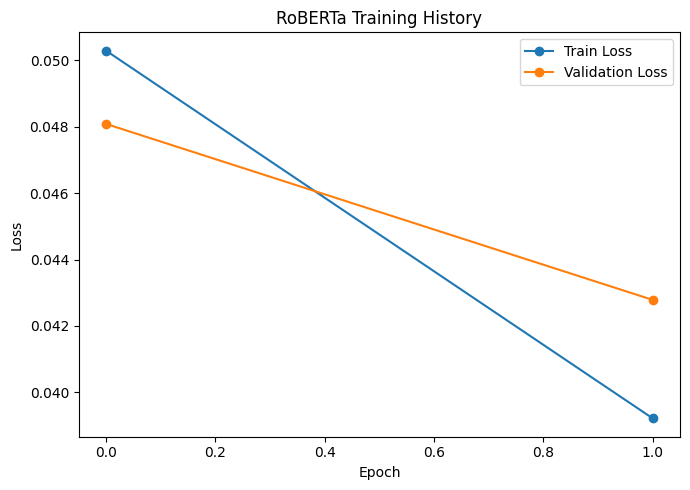

Saved figure to: c:\Users\farha\code\classical model vs fine tuned transformer vs LLM prompting\figures\roberta_training_history.png


In [12]:
# Phase K: Plot training and validation loss

plt.figure(figsize=(7, 5))
plt.plot(history["train_loss"], marker="o", label="Train Loss")
plt.plot(history["val_loss"], marker="o", label="Validation Loss")
plt.title("RoBERTa Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

loss_plot_path = FIGURES_DIR / "roberta_training_history.png"
plt.savefig(loss_plot_path, dpi=300)
plt.show()

print("Saved figure to:", loss_plot_path)

In [13]:
# Phase L: Reload best model and compute probabilities

model.load_state_dict(torch.load(best_model_path, map_location=device))

val_loss, val_probs, val_labels = get_probs_and_labels(model, val_loader, device)
test_loss, test_probs, test_labels = get_probs_and_labels(model, test_loader, device)

print("Validation probabilities shape:", val_probs.shape)
print("Test probabilities shape:", test_probs.shape)
print("Validation loss:", val_loss)
print("Test loss:", test_loss)

Evaluating:   0%|          | 0/2992 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/2992 [00:00<?, ?it/s]

Validation probabilities shape: (23936, 6)
Test probabilities shape: (23936, 6)
Validation loss: 0.04278479809532256
Test loss: 0.042755582507868865


In [14]:
# Phase M: Tune one threshold per label using validation F1

threshold_grid = np.arange(0.10, 0.91, 0.05)
best_thresholds = {}

for i, label in enumerate(label_cols):
    best_f1 = -1
    best_threshold = 0.5

    for threshold in threshold_grid:
        preds = (val_probs[:, i] >= threshold).astype(int)
        score = f1_score(val_labels[:, i], preds, zero_division=0)

        if score > best_f1:
            best_f1 = score
            best_threshold = threshold

    best_thresholds[label] = best_threshold

threshold_df = pd.DataFrame({
    "label": list(best_thresholds.keys()),
    "best_threshold": list(best_thresholds.values())
})

display(threshold_df)

threshold_path = RESULTS_DIR / "roberta_best_thresholds.csv"
threshold_df.to_csv(threshold_path, index=False)
print("Saved thresholds to:", threshold_path)

,label,best_threshold
0,toxic,0.45
1,severe_toxic,0.50
2,obscene,0.55
3,threat,0.40
4,insult,0.50
5,identity_hate,0.70


Saved thresholds to: c:\Users\farha\code\classical model vs fine tuned transformer vs LLM prompting\results\roberta_best_thresholds.csv


In [15]:
# Phase N: Convert probabilities into final binary predictions

test_preds = np.zeros_like(test_probs, dtype=int)

for i, label in enumerate(label_cols):
    threshold = best_thresholds[label]
    test_preds[:, i] = (test_probs[:, i] >= threshold).astype(int)

print("Test prediction matrix shape:", test_preds.shape)

Test prediction matrix shape: (23936, 6)


In [16]:
# Phase O: Compute overall metrics

micro_f1 = f1_score(test_labels, test_preds, average="micro", zero_division=0)
macro_f1 = f1_score(test_labels, test_preds, average="macro", zero_division=0)

pr_auc_per_label = {}
for i, label in enumerate(label_cols):
    pr_auc_per_label[label] = average_precision_score(test_labels[:, i], test_probs[:, i])

mean_pr_auc = np.mean(list(pr_auc_per_label.values()))

overall_metrics = pd.DataFrame({
    "metric": ["micro_f1", "macro_f1", "mean_pr_auc", "test_loss"],
    "value": [micro_f1, macro_f1, mean_pr_auc, test_loss]
})

display(overall_metrics)

,metric,value
0,micro_f1,0.780240
1,macro_f1,0.669110
2,mean_pr_auc,0.710015
3,test_loss,0.042756


In [17]:
# Phase P: Compute per-label F1 and PR-AUC

per_label_rows = []

for i, label in enumerate(label_cols):
    label_f1 = f1_score(test_labels[:, i], test_preds[:, i], zero_division=0)
    label_pr_auc = average_precision_score(test_labels[:, i], test_probs[:, i])

    per_label_rows.append({
        "label": label,
        "f1": label_f1,
        "pr_auc": label_pr_auc
    })

per_label_metrics = pd.DataFrame(per_label_rows)
display(per_label_metrics)

,label,f1,pr_auc
0,toxic,0.820981,0.904151
1,severe_toxic,0.537037,0.533040
2,obscene,0.828942,0.906805
3,threat,0.526786,0.512115
4,insult,0.761828,0.826839
5,identity_hate,0.539084,0.577137


In [18]:
# Phase Q: Save outputs for the paper and later analysis

overall_metrics_path = RESULTS_DIR / "roberta_overall_metrics.csv"
per_label_metrics_path = RESULTS_DIR / "roberta_per_label_metrics.csv"
predictions_path = RESULTS_DIR / "roberta_test_predictions.csv"

overall_metrics.to_csv(overall_metrics_path, index=False)
per_label_metrics.to_csv(per_label_metrics_path, index=False)

predictions_df = test_df[["id", "comment_text"]].copy()
for i, label in enumerate(label_cols):
    predictions_df[f"{label}_true"] = test_labels[:, i]
    predictions_df[f"{label}_prob"] = test_probs[:, i]
    predictions_df[f"{label}_pred"] = test_preds[:, i]

predictions_df.to_csv(predictions_path, index=False)

print("Saved:")
print(overall_metrics_path)
print(per_label_metrics_path)
print(predictions_path)

Saved:
c:\Users\farha\code\classical model vs fine tuned transformer vs LLM prompting\results\roberta_overall_metrics.csv
c:\Users\farha\code\classical model vs fine tuned transformer vs LLM prompting\results\roberta_per_label_metrics.csv
c:\Users\farha\code\classical model vs fine tuned transformer vs LLM prompting\results\roberta_test_predictions.csv


In [19]:
# Phase R: Print a readable classification report for each label

for i, label in enumerate(label_cols):
    print(f"\n===== {label} =====")
    print(classification_report(
        test_labels[:, i],
        test_preds[:, i],
        zero_division=0
    ))


===== toxic =====
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98     21640
         1.0       0.80      0.84      0.82      2296

    accuracy                           0.96     23936
   macro avg       0.89      0.91      0.90     23936
weighted avg       0.97      0.96      0.97     23936


===== severe_toxic =====
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     23703
         1.0       0.47      0.62      0.54       233

    accuracy                           0.99     23936
   macro avg       0.73      0.81      0.77     23936
weighted avg       0.99      0.99      0.99     23936


===== obscene =====
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     22665
         1.0       0.78      0.88      0.83      1271

    accuracy                           0.98     23936
   macro avg       0.89      0.93      0.91     23936
weighted

In [20]:
comparison_df = pd.DataFrame({
    "model": ["Classical TF-IDF + Logistic Regression", "RoBERTa Fine-Tuning"],
    "micro_f1": [0.730514, 0.780240],
    "macro_f1": [0.604852, 0.669110],
    "mean_pr_auc": [0.634141, 0.710015]
})

comparison_df.to_csv(RESULTS_DIR / "model_comparison_so_far.csv", index=False)
comparison_df

,model,micro_f1,macro_f1,mean_pr_auc
0,Classical TF-IDF + Logistic Regression,0.730514,0.604852,0.634141
1,RoBERTa Fine-Tuning,0.780240,0.669110,0.710015
